In [1]:
import sys
import pathlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sigutils

EXAMPLES = pathlib.Path(".").absolute()
BUILD = EXAMPLES.parent / "build" / "pyrendering"
sys.path.insert(0, str(BUILD))
sys.path.insert(0, str(EXAMPLES))
import pyrendering as pr

In [2]:
pr.init(validation_layers=False)

In [3]:
def apply_colormap(hist: np.ndarray, cm, log_min: float = 0.05) -> np.ndarray:
    peak = hist.max()
    if peak > log_min:
        log_range = np.log(peak) - np.log(log_min)
        normalized = (np.log(np.clip(hist, log_min, peak)) - np.log(log_min)) / log_range
    else:
        normalized = np.zeros_like(hist)
    return (cm(normalized) * 255).astype(np.uint8)


In [4]:
def render_signal(x, width: int = 1920, height: int = 1080, line_width=1e-3, x_range=(0, 1), y_range=(-1.5, 1.5)):
    hist = pr.Histogram(width, height)
    hist.clear()
    hist.draw_waveform(x, x_range=x_range, y_range=y_range, line_width=line_width)
    
    data = hist.download()
    
    print(f"Histogram: shape={data.shape}, min={data.min():.4f}, max={data.max():.4f}")
    out = data.copy()
    del hist
    return out

In [5]:
def render_square_wave(width: int = 1920, height: int = 1080, line_width=1e-3) -> None:
    rng = np.random.default_rng(42)
    n = 1_000_000

    # 2 periods of a square wave, noise std = 0.1
    half_period = n // 4  # 4 half-periods = 2 full periods
    square = np.where((np.arange(n) // half_period) % 2 == 0, 1.0, -1.0).astype(np.float32)
    signal = square + 0.1 * rng.standard_normal(n).astype(np.float32)

    hist = pr.Histogram(width, height)
    hist.clear()
    hist.draw_waveform(signal, x_range=(0.0, 1.0), y_range=(-1.5, 1.5), line_width=line_width)

    data = hist.download()
    print(f"Histogram: shape={data.shape}, min={data.min():.4f}, max={data.max():.4f}")
    out = data.copy()
    del hist
    return out

In [6]:
N = 2**20

Histogram: shape=(1080, 1920), min=0.0000, max=1290.0000


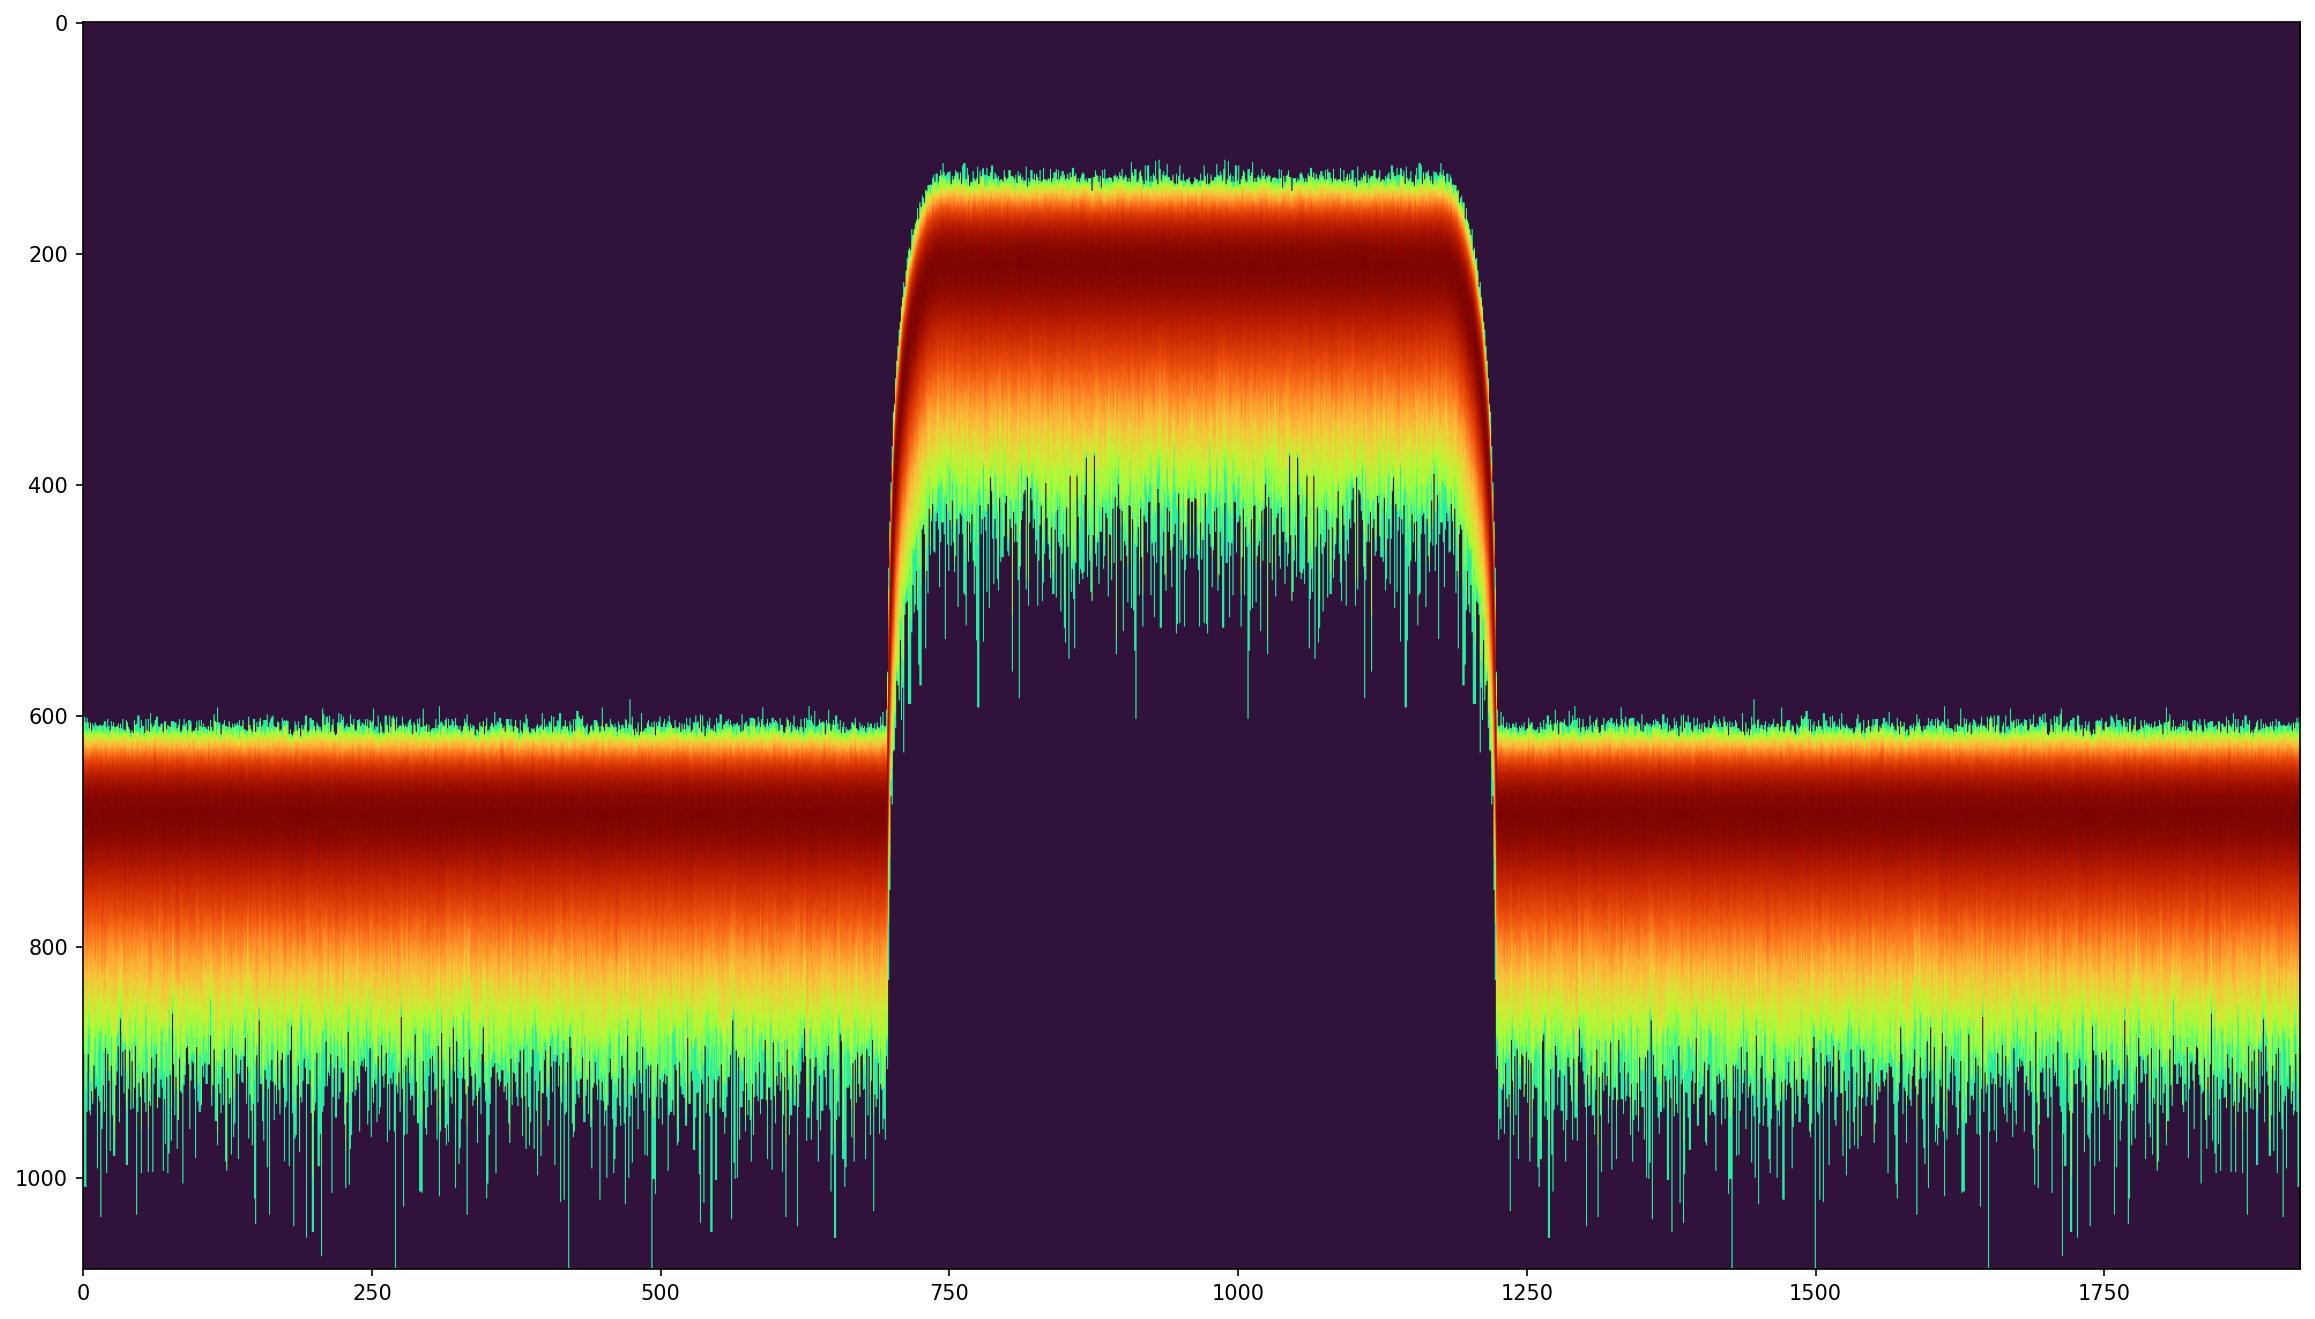

In [15]:
# hist = render_signal(np.sin(2*np.pi*np.linspace(0, 1, N)) + 0.05 * np.random.randn(N))
sig = sigutils.rcf_signal(N, 4, 0.1, np.array([-1, 1]), filter_length=128)
sig += 1e-3 * np.random.randn(sig.size)

spec = 20 * np.log10(np.fft.fftshift(np.abs(np.fft.fft(sig))))

hist = render_signal(spec, y_range=(-50, 100))

plt.figure(figsize=(19.2,10.8), dpi=150)
plt.imshow(apply_colormap(hist, cm=plt.cm.turbo))

In [ ]:
hist = render_signal(np.sin(2*np.pi*np.linspace(0, 1, N)) + 0.05 * np.random.randn(N))

plt.figure(figsize=(19.2,10.8))
plt.imshow(apply_colormap(hist, cm=plt.cm.inferno))

In [ ]:
pr.shutdown()